# **Stack Overflow Salary Prediction**
### A CRISP-DM Based Data Science Project

This project analyzes data from the Stack Overflow Developer Survey to understand
the relationship between professional coding experience and developer salary.
The analysis follows the CRISP-DM framework to ensure clarity, transparency,
and reproducibility.

## **1. Business Understanding**

The technology industry shows wide variation in developer compensation.
Understanding the factors that influence salary can help individuals make
informed career decisions and help organizations design competitive compensation
strategies.

### Objectives
- Explore how professional coding experience relates to salary
- Understand the distribution of developer salaries
- Build a predictive model to estimate whether a developer earns above the median salary

## **2. Business Questions**

To guide this analysis, the following business questions are addressed:

1. How does professional coding experience relate to salary?
2. What does the distribution of developer salaries look like?
3. Are developers with more experience more likely to earn above the median salary?
4. Can a machine learning model predict whether a developer earns above the median salary?


## **3. Data Understanding**

In this section, the dataset structure is explored to understand:
- Available features
- Data types
- Presence of missing values

This step is critical to determine which cleaning and preparation steps are required
before analysis and modeling.

## **Environment Setup**

In this section, we import the required Python libraries for data analysis,
visualization, and machine learning. These libraries will be used throughout
the notebook.

In [3]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Visualization settings
sns.set(style="whitegrid")

## **1. Data Loading**

The dataset used in this analysis comes from the Stack Overflow Developer Survey.
It contains responses from developers worldwide related to experience, salary,
and professional background.

The dataset is loaded into a Pandas DataFrame for analysis.

In [4]:
# Load the dataset
df = pd.read_csv("survey_results_public.csv")

# Display first few rows
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## **2. Data Understanding**

In this step, we explore the structure of the dataset to understand:
- Number of rows and columns
- Data types of each feature
- Presence of missing values

This helps identify necessary cleaning steps.

In [5]:
# Overview of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


In [6]:
# Statistical summary of numeric features
df.describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


In [7]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

,0
AINextMuch less integrated,64289
AINextLess integrated,63082
AINextNo change,52939
AINextMuch more integrated,51999
EmbeddedAdmired,48704
...,...
MainBranch,0
Age,0
Employment,0
Check,0




---



## **3. Data Cleaning and Preparation**

For modeling, we focus on professional coding experience and salary.

Rows with missing values in these key features are removed because:
- The proportion of missing values is relatively small
- Removing them avoids introducing bias from imputation
- The remaining data is sufficient for analysis

In [8]:
# Select relevant columns
df_model = df[['YearsCodePro', 'ConvertedCompYearly']].dropna()

### Converting Experience to Numeric Format

The `YearsCodePro` feature includes non-numeric values such as
"Less than 1 year" and "More than 50 years".

These values are converted into numeric equivalents to ensure
compatibility with machine learning models while preserving order.

In [9]:
def convert_years(value):
    """Convert YearsCodePro to numeric form."""
    if value == "Less than 1 year":
        return 0.5
    elif value == "More than 50 years":
        return 50
    else:
        return float(value)

df_model['YearsCodeProNumeric'] = df_model['YearsCodePro'].apply(convert_years)



---



## **4. Feature Engineering**

Salary is converted into a binary target variable:
- 1 → Salary above the median
- 0 → Salary below the median

The median is used instead of the mean because salary distributions
are typically right-skewed.

In [10]:
# Calculate median salary
median_salary = df_model['ConvertedCompYearly'].median()

# Create binary target variable
df_model['AboveMedianSalary'] = (
    df_model['ConvertedCompYearly'] > median_salary
).astype(int)



---



## **Question 1: How does professional coding experience relate to salary?**

### Hypothesis
Developers with more years of professional coding experience tend to earn higher salaries.

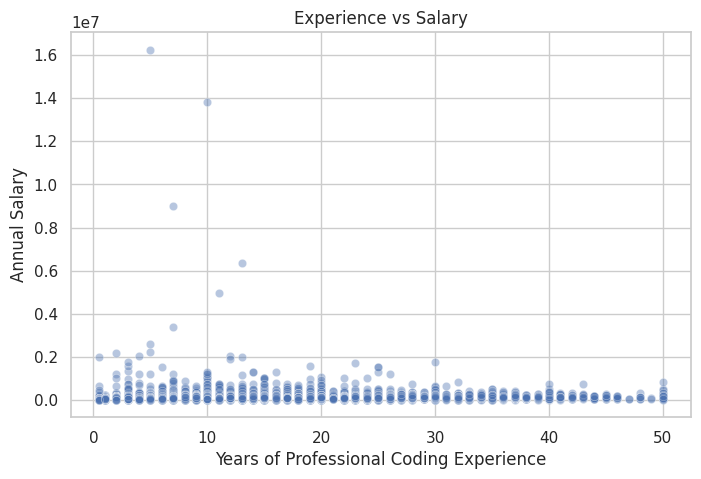

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=df_model['YearsCodeProNumeric'],
    y=df_model['ConvertedCompYearly'],
    alpha=0.4
)
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Annual Salary")
plt.title("Experience vs Salary")
plt.show()

### Conclusion
The plot shows a positive relationship between experience and salary.
As professional experience increases, salary tends to increase as well,
supporting the hypothesis.



---



## **Question 2: What does the distribution of developer salaries look like?**

### Hypothesis
Developer salaries are right-skewed, with a small number of very high earners.

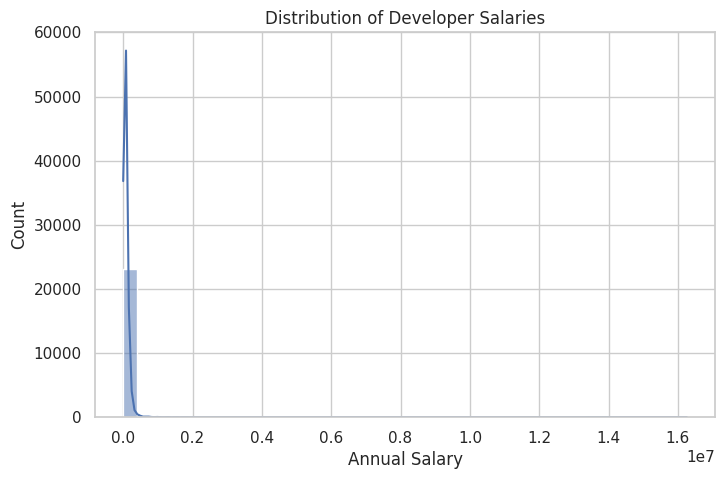

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df_model['ConvertedCompYearly'], bins=40, kde=True)
plt.xlabel("Annual Salary")
plt.title("Distribution of Developer Salaries")
plt.show()

### **Conclusion**
The salary distribution is right-skewed, meaning most developers earn
moderate salaries while a smaller group earns significantly more.



---



## **Question 3: Are more experienced developers more likely to earn above the median salary?**

### Hypothesis
Developers with greater experience are more likely to earn above the median salary.

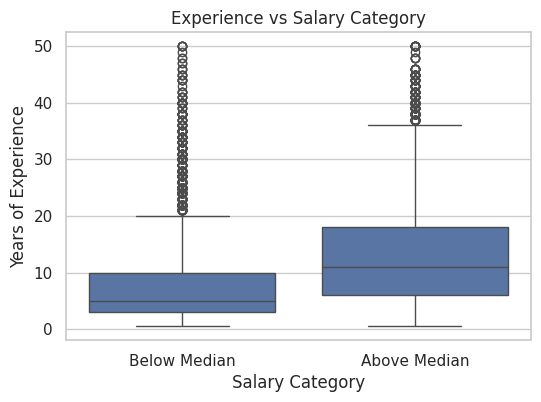

In [13]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    x='AboveMedianSalary',
    y='YearsCodeProNumeric',
    data=df_model
)
plt.xticks([0, 1], ["Below Median", "Above Median"])
plt.xlabel("Salary Category")
plt.ylabel("Years of Experience")
plt.title("Experience vs Salary Category")
plt.show()

### Conclusion
Developers earning above the median salary generally have more professional experience,
supporting the hypothesis.



---



## **6. Modeling**

A logistic regression model is used because:
- The target variable is binary
- The model is interpretable
- It is suitable for classification problems

In [14]:
# Define features and target
X = df_model[['YearsCodeProNumeric']]
y = df_model['AboveMedianSalary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()



---



## 7. Model Evaluation

Model performance is evaluated using:
- Accuracy: overall correctness
- Precision: correctness of positive predictions
- Recall: ability to identify actual positive cases

In [15]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

accuracy, precision, recall

(0.6686656671664168, 0.6995905834186285, 0.5874516544907606)

### **Evaluation Conclusion**
The model demonstrates reasonable predictive performance, indicating that
professional experience alone provides meaningful insight into salary outcomes.



---



## **8. Prediction Scenario**

Consider a developer with 5 years of professional coding experience.
The model is used to predict whether this developer earns above the median salary.

In [17]:
model.predict(pd.DataFrame([[5]], columns=['YearsCodeProNumeric']))

array([0])

### **Interpretation**
The model outputs a binary prediction indicating whether the developer
is likely to earn above or below the median



---



## **9. Final Conclusion**

The model predicts that a developer with 5 years of experience earns below the median salary, which aligns with the visual analysis showing that above‑median earners typically have higher experience levels. The evaluation metrics indicate reasonable predictive performance for a single‑feature model, confirming that professional experience is an important—but not exclusive—factor in salary outcomes.